In [1]:
import yaml
import numpy as np
import polars as pl
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
mac = 20
pheno_list_type = None

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds_categories.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""genomic_region""","""mane_cds""","""#E31A1C""","""MANE CDS""",1
"""genomic_region""","""non_mane_cds""","""#FB9A99""","""Other CDS""",1
"""genomic_region""","""mane_exonic""","""#33A02C""","""MANE Exon""",1
"""genomic_region""","""non_mane_exonic""","""#B2DF8A""","""Other Exon""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
…,…,…,…,…
"""encode_enhancer""","""encode_ca_ctcf""","""#4DAF4A""","""Accessible Region with CTCF Bi…",1
"""encode_enhancer""","""encode_ca""","""#377EB8""","""Chromatin Accessible""",1
"""encode_enhancer""","""encode_ca_tf""","""#1D6498""","""Accessible Region with TF Bind…",1


In [3]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated/annotations_fillna_ukbgym.parquet -o /home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet

# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated/annotations_ukbgym.parquet -o /home/dnanexus/data_dir/annotations_ukbgym.parquet

Error: path "/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet"
already exists but -f/--overwrite was not set


In [4]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet")

min_range = -500
max_range = +500

anno = (
    anno
    .with_columns(
        encode_eh_pr = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_pels', 'encode_dels']),
        encode_all_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca-tf']),
        encode_annotated = pl.col('not_annotated_in_encode') == False,
    )
    .filter(
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True)
        # ((pl.col('vep_cds_relaxed')==True) | (pl.col('mane_cds')==True))
        # (pl.col('non_mane_cds')==False)

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False))

        # Choose VEP consequence
        # (pl.col('consequence_missense_variant') == True)
        # (pl.col('consequence_upstream_gene_variant') == True)
        # (pl.col('consequence_downstream_gene_variant') == True)
        # (pl.col('consequence_intron_variant') == True)

        # (pl.col('dist_to_tss') < max_range) &
        # (pl.col('dist_to_tss') > min_range)
        
        # Choose Gene Body
        # ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False))

        # Choose regulatory region
        # (pl.col('not_in_encode') == False)
        # (pl.col('encode_eh_pr') == True) &
        # (pl.col('encode_all_tf') == True) &
    )
    
    # .with_columns(
    #     loftee_disorder = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_curated_disorder_priority']),
    #     loftee_lip = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_lip_full']),
    #     loftee_ted = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'ted_domain']),
    #     loftee_low_complexity = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'low_complexity_domain']),
    # )
    .with_columns(
        indel_length = (pl.col('ref').str.len_chars() - pl.col('alt').str.len_chars()).abs(),
        insertion = pl.when(pl.col('ref').str.len_chars() < pl.col('alt').str.len_chars()).then(True).otherwise(False),
        deletion = pl.when(pl.col('ref').str.len_chars() > pl.col('alt').str.len_chars()).then(True).otherwise(False),
    )
    .with_columns(
        # --- Indel CDS categories ---
        deletion_x3bp = pl.when(pl.col('deletion') & (pl.col('indel_length') %3 == 0)).then(True).otherwise(False),
        deletion_not_x3bp = pl.when(pl.col('deletion') & (pl.col('indel_length') %3 != 0)).then(True).otherwise(False),
        insertion_x3bp = pl.when(pl.col('insertion') & (pl.col('indel_length') %3 == 0)).then(True).otherwise(False),
        insertion_not_x3bp = pl.when(pl.col('insertion') & (pl.col('indel_length') %3 != 0)).then(True).otherwise(False),

        # --- Indel length categories ---
        deletion_gt2bp = pl.when(pl.col('indel_length') >= 2).then(True).otherwise(False) & pl.col('deletion'),
        deletion_gt5bp = pl.when(pl.col('indel_length') >= 5).then(True).otherwise(False) & pl.col('deletion'),
        insertion_gt2bp = pl.when(pl.col('indel_length') >= 2).then(True).otherwise(False) & pl.col('insertion'),
        insertion_gt5bp = pl.when(pl.col('indel_length') >= 5).then(True).otherwise(False) & pl.col('insertion'),
    )
    .with_columns(
        # --- ENCODE indels ---
        encode_deletion = pl.when(pl.col('deletion') & (pl.col('encode_annotated')==True)).then(True).otherwise(False),
        encode_insertion = pl.when(pl.col('insertion') & (pl.col('encode_annotated')==True)).then(True).otherwise(False),
        encode_snp = pl.when((pl.col('encode_annotated')==True) & (pl.col('deletion')==False) & (pl.col('insertion')==False)).then(True).otherwise(False),

        # --- ENCODE deletions ---
        encode_deletion_gt2bp = pl.when((pl.col('indel_length') >= 2) & (pl.col('encode_annotated')==True)).then(True).otherwise(False) & pl.col('deletion'),
        encode_deletion_gt5bp = pl.when((pl.col('indel_length') >= 5) & (pl.col('encode_annotated')==True)).then(True).otherwise(False) & pl.col('deletion'),
    )
)

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .select(
        set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

five_prime_utr_variant_consequence_ustop_lost,insertion_gt5bp,encode_annotated,consequence_splice_donor_variant,loftee_lc,five_prime_utr_variant_consequence_uaug_gained,encode_tf,five_prime_utr_variant_consequence_ustop_gained,encode_dels,insertion_not_x3bp,gene_length,id,deletion,consequence_start_lost,insertion_gt2bp,consequence_stop_gained,deletion_x3bp,deletion_not_x3bp,encode_all_tf,loftee_hc,ted_domain,low_complexity_domain,encode_pels,strand,gene_name,deletion_gt5bp,mobi_curated_disorder_priority,encode_ca,five_prime_utr_variant_consequence_uaug_lost,dist_to_tss,encode_snp,encode_deletion_gt2bp,insertion_x3bp,encode_deletion,consequence_missense_variant,consequence_frameshift_variant,encode_eh_pr,consequence_splice_acceptor_variant,consequence_stop_lost,deletion_gt2bp,five_prime_utr_variant_consequence_uframeshift,encode_pls,region,encode_insertion,insertion,encode_deletion_gt5bp,mobi_lip_full,tss
u8,bool,bool,i8,i8,u8,bool,u8,bool,bool,i64,str,bool,i8,bool,i8,bool,bool,bool,i8,bool,bool,bool,cat,str,bool,bool,bool,u8,i64,bool,bool,bool,bool,i8,i8,bool,i8,i8,bool,u8,bool,str,bool,bool,bool,bool,i64
0,false,true,0,0,0,false,0,true,false,103372,"""chr2:26136528:A:G""",false,0,false,0,false,false,false,0,false,false,false,"""+""","""RAB10""",false,false,false,0,102445,true,false,false,false,0,0,true,0,0,false,0,false,"""ENSG00000084733""",false,false,false,false,26034083
0,false,false,0,0,0,false,0,false,false,101404,"""chr2:233771145:C:T""",false,0,false,0,false,false,false,0,false,false,false,"""+""","""UGT1A9""",false,false,false,0,99248,false,false,false,false,0,0,false,0,0,false,0,false,"""ENSG00000241119""",false,false,false,false,233671897
0,false,false,0,0,0,false,0,false,false,411117,"""chr12:101117325:T:G""",false,0,false,0,false,false,false,0,false,false,false,"""+""","""ANO4""",false,false,false,0,399800,false,false,false,false,0,0,false,0,0,false,0,false,"""ENSG00000151572""",false,false,false,false,100717525
0,false,false,0,0,0,false,0,false,false,427429,"""chr10:25235985:T:G""",false,0,false,0,false,false,false,0,false,false,false,"""+""","""GPR158""",false,false,false,0,61184,false,false,false,false,0,0,false,0,0,false,0,false,"""ENSG00000151025""",false,false,false,false,25174801
0,true,false,0,0,0,false,0,false,false,309704,"""chr7:80447426:C:CA""",false,0,true,0,false,false,false,0,false,false,false,"""+""","""CD36""",false,false,false,0,77852,false,false,true,false,0,0,false,0,0,false,0,false,"""ENSG00000135218""",false,true,false,false,80369574
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,false,false,0,0,0,false,0,false,false,744168,"""chr7:90733917:A:C""",false,0,false,0,false,false,false,0,false,false,false,"""+""","""CDK14""",false,false,false,0,267494,false,false,false,false,0,0,false,0,0,false,0,false,"""ENSG00000058091""",false,false,false,false,90466423
0,false,false,0,0,0,false,0,false,false,90960,"""chr18:754318:C:G""",false,0,false,0,false,false,false,0,false,false,false,"""-""","""YES1""",false,false,false,0,58228,false,false,false,false,0,0,false,0,0,false,0,false,"""ENSG00000176105""",false,false,false,false,812546
0,false,true,0,0,0,false,0,true,false,122975,"""chr3:97895184:G:C""",false,0,false,0,false,false,false,0,false,false,false,"""+""","""CRYBG3""",false,false,false,0,73174,true,false,false,false,0,0,true,0,0,false,0,false,"""ENSG00000080200""",false,false,false,false,97822010


In [5]:
selected_annos = anno_config_df.filter(
    # pl.col('category').is_in(['genomic_region']) # genomic_region
    # pl.col('category').is_in(['plof_consequences']) # plof consequences
    # pl.col('annotation').is_in(['loftee_hc', 'loftee_lc']) # loftee consequences

    # pl.col('category').is_in(['plof', 'missense']) # CDS
    # pl.col('category').is_in(['protein_domains']) # Protein Domains
    # pl.col('category').is_in(['loftee_protein_domains']) # LOFTEE Protein Domains

    # pl.col('category').is_in(['indel_cds']) # CDS indels
    # pl.col('category').is_in(['indel_categories']) # indel length
    # pl.col('category').is_in(['encode_indels']) # encode indels
    pl.col('category').is_in(['encode_deletions']) # encode deletions
    
    # pl.col('category').is_in(['encode_boolean']) # encode
    # pl.col('category').is_in(['encode_custom']) # encode custom regions
    # pl.col('category').is_in(['indel_categories', '5utr_annotator', 'encode_boolean']) # 5utr
)['annotation'].to_list()

# Handle fillna annotations
anno_fillna = pl.scan_parquet("/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet")
fillna_cols = set([c+'_is_na' for c in selected_annos]).intersection(set(anno_fillna.collect_schema().names()))

anno_fillna_melted = (
    anno_fillna
    .select(['id', 'region', 'gene_name'] + list(fillna_cols))
    .join(
        anno.select(['id', 'region', 'gene_name']).lazy(), 
        on=['id', 'region', 'gene_name'], 
        how='semi'
    )
    .unpivot(
        index=["id", "region", "gene_name"],
        on=list(fillna_cols),
        variable_name="annotation",
        value_name="annotation_is_na"
    )
    .filter(
        pl.col('annotation_is_na') == False
    )
    .with_columns(
        annotation = pl.col('annotation').str.replace('_is_na$', '')
    )
    # .collect(engine='streaming')
)

melted_anno = (
    anno

    .select(
        set(['id', 'region', 'gene_name']).union(set(selected_annos))
    )   

    .unpivot(
        index=["id", "region", "gene_name"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]),
        on="annotation",
        how="left"
    )
    .with_columns(
        # annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir")
        annotation_score_dircor = (
            pl.when(pl.col("annotation_dir")!=1)
            .then((pl.col('annotation_score')-1).abs())
            .otherwise(pl.col('annotation_score'))
        )
    )

    # .drop_nulls()
    # .filter(pl.col('annotation_score').is_not_null())
)

melted_anno

id,region,gene_name,annotation,annotation_score,category,annotation_dir,annotation_score_dircor
str,str,str,str,f32,str,i8,f32
"""chr2:26136528:A:G""","""ENSG00000084733""","""RAB10""","""encode_snp""",1.0,"""encode_indels""",1,1.0
"""chr2:26136528:A:G""","""ENSG00000084733""","""RAB10""","""encode_snp""",1.0,"""encode_deletions""",1,1.0
"""chr2:233771145:C:T""","""ENSG00000241119""","""UGT1A9""","""encode_snp""",0.0,"""encode_indels""",1,0.0
"""chr2:233771145:C:T""","""ENSG00000241119""","""UGT1A9""","""encode_snp""",0.0,"""encode_deletions""",1,0.0
"""chr12:101117325:T:G""","""ENSG00000151572""","""ANO4""","""encode_snp""",0.0,"""encode_indels""",1,0.0
…,…,…,…,…,…,…,…
"""chr7:90733917:A:C""","""ENSG00000058091""","""CDK14""","""encode_deletion_gt5bp""",0.0,"""encode_deletions""",1,0.0
"""chr18:754318:C:G""","""ENSG00000176105""","""YES1""","""encode_deletion_gt5bp""",0.0,"""encode_deletions""",1,0.0
"""chr3:97895184:G:C""","""ENSG00000080200""","""CRYBG3""","""encode_deletion_gt5bp""",0.0,"""encode_deletions""",1,0.0


In [6]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet -o /home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet

appv = pl.scan_parquet("/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value_ptile', 'n_individuals']
    )
)
# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

Error: path "/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrela
ted_appv_percentiles.parquet" already exists but -f/--overwrite was not set


In [7]:
# Get gene trait associations
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet -o /home/dnanexus/data_dir/
# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/loftee_mac20_associations_bh_corrected.parquet -o /home/dnanexus/data_dir/

!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet -o /home/dnanexus/data_dir/

gene_trait_df = (
    pl.read_parquet('/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

loftee_corrs = (
    pl.read_parquet('/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    # .sort('loftee_corr_abs', descending=True)
    # .sort('pval_fdr')
    # .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path
"/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet"
already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000067900""","""lymphocyte_count_int""",0.015659,-0.097882,0.097882,-1.0
"""ENSG00000145386""","""mean_corpuscular_haemoglobin_i…",0.000096,-0.059845,0.059845,-1.0
"""ENSG00000164944""","""trunk_predicted_mass_int""",0.015511,-0.04623,0.04623,-1.0
"""ENSG00000107863""","""trunk_predicted_mass_int""",0.033889,-0.122605,0.122605,-1.0
"""ENSG00000121966""","""eosinophill_percentage_int""",0.000392,-0.075765,0.075765,-1.0
…,…,…,…,…,…
"""ENSG00000142208""","""arm_predicted_mass_right_int""",0.009537,-0.049973,0.049973,-1.0
"""ENSG00000101670""","""cholesterol_int""",0.000099,0.035791,0.035791,1.0
"""ENSG00000017427""","""weight_int""",0.000158,-0.170599,0.170599,-1.0


In [8]:
n_steps = 101
or_threshold_pheno_left = 1
or_threshold_pheno_right = 1e-4

cutoffs_list = 1 - np.logspace(
    np.log10(or_threshold_pheno_left),
    np.log10(or_threshold_pheno_right),
    num=n_steps
)

pheno_cutoffs_lazy = pl.LazyFrame({"pheno_cutoff": cutoffs_list.tolist()})

pheno_cutoffs_lazy.collect()

pheno_cutoff
f64
0.0
0.087989
0.168236
0.241422
0.308169
…
0.999855
0.999868
0.99988


In [9]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())

# --- Build main query (same as before, but stop before group_by) ---
gp_lazy = (
    appv
    # Select required variants
    .join(
        anno_ids_lazy, 
        on="id", 
        how="semi"
    )
    # Merge annotation scores
    .join(
        melted_anno.lazy(),
        on="id", 
        how="inner"
    )
    # Merge with gene_trait_df
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.when(pl.col('loftee_corr_dir') == -1) # To get 1/100, 1/1000, etc.
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
    
    # Cross join with cutoffs and compute odds ratios
    .join(
        pheno_cutoffs_lazy, 
        how="cross"
    )
    .group_by(["annotation", "region", "gene_name", "phenotype", "pheno_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("annotation_score_dircor") == 1) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= pl.col("pheno_cutoff"))
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("annotation_score_dircor") == 1) & 
            (pl.col("mean_pheno_value_dircor_ptile") < pl.col("pheno_cutoff"))
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("annotation_score_dircor") == 0) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= pl.col("pheno_cutoff"))
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("annotation_score_dircor") == 0) & 
            (pl.col("mean_pheno_value_dircor_ptile") < pl.col("pheno_cutoff"))
        ).sum()
    )
    .with_columns(
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
)

# Execute
print("Executing with odds ratios...")
or_df = gp_lazy.collect(engine='streaming').sort('pheno_cutoff')

or_df

Executing with odds ratios...


annotation,region,gene_name,phenotype,pheno_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,str,f64,u64,u64,u64,u64,f64
"""encode_snp""","""ENSG00000175445""","""LPL""","""apolipoprotein_a_int""",0.0,7720,0,33322,0,NaN
"""encode_deletion_gt2bp""","""ENSG00000164151""","""ICE1""","""arm_predicted_mass_right_int""",0.0,189,0,18395,0,NaN
"""encode_deletion""","""ENSG00000150961""","""SEC24D""","""arm_predicted_mass_right_int""",0.0,968,0,49574,0,NaN
"""encode_deletion""","""ENSG00000128641""","""MYO1B""","""basal_metabolic_rate_int""",0.0,1408,0,78848,0,NaN
"""encode_snp""","""ENSG00000196531""","""NACA""","""creatinine_int""",0.0,3930,0,8048,0,NaN
…,…,…,…,…,…,…,…,…,…
"""encode_deletion_gt5bp""","""ENSG00000164880""","""INTS1""","""reticulocyte_percentage_int""",0.9999,0,90,0,13835,NaN
"""encode_deletion_gt5bp""","""ENSG00000011028""","""MRC2""","""standing_height_int""",0.9999,6,136,423,16869,1.759387
"""encode_deletion_gt5bp""","""ENSG00000073792""","""IGF2BP2""","""standing_height_int""",0.9999,5,214,425,43162,2.372842


In [10]:
# or_df = pl.read_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_all_vars_{or_threshold_pheno}_wgs_EUR_genebass1e6_maf1e3.parquet')

print('unique percentile cutoffs:', or_df['pheno_cutoff'].n_unique())

plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        n_gene_phenos = pl.len().over(['pheno_cutoff', 'annotation']),
        pheno_cutoff_inv = 1 - pl.col('pheno_cutoff'),
    )
    .with_columns(
        neg_log_pheno_cutoff_inv = -np.log10(pl.col('pheno_cutoff_inv')),
        med_odds_ratio = pl.col('odds_ratio').median().over(['pheno_cutoff_inv', 'annotation']),
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['pheno_cutoff_inv', 'annotation']),
        se_odds_ratio = pl.col('odds_ratio').std().over(['pheno_cutoff_inv', 'annotation'])/(pl.col('n_gene_phenos').sqrt()),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('se_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('se_odds_ratio')),
    )
    .select(['annotation', 'neg_log_pheno_cutoff_inv', 'pheno_cutoff', 'pheno_cutoff_inv', 'n_gene_phenos', 'med_odds_ratio', 'avg_odds_ratio', 'se_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    
    # join plotting info
    .join(
        anno_config_df.select(['annotation', 'color', 'label']),
        on='annotation',
        how='left'
    )
    .sort('pheno_cutoff_inv')

    # Remove data points without ci or with or=0
    .filter(
        (pl.col('annotation')!='core_promoter') &
        (pl.col('std_ci_upper').is_not_null()) &
        (pl.col('std_ci_lower').is_not_null()) &
        (pl.col('n_gene_phenos') >= 10) &
        (pl.col('avg_odds_ratio') > 0) &
        (pl.col('std_ci_lower') > 0)
    )
)

plt_df

unique percentile cutoffs: 101


annotation,neg_log_pheno_cutoff_inv,pheno_cutoff,pheno_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,f64,f64,u64,f64,f64,f64,f64,f64,str,str
"""encode_snp""",4.0,0.9999,0.0001,1274,0.989563,1.032457,0.018019,1.067774,0.99714,"""peru""","""ENCODE annotated SNP"""
"""encode_snp""",4.0,0.9999,0.0001,1274,0.989563,1.032457,0.018019,1.067774,0.99714,"""peru""","""ENCODE annotated SNP"""
"""encode_deletion""",4.0,0.9999,0.0001,1274,1.098961,1.294486,0.044677,1.382053,1.206918,"""#005A32""","""ENCODE annotated Deletion"""
"""encode_deletion""",4.0,0.9999,0.0001,1274,1.098961,1.294486,0.044677,1.382053,1.206918,"""#238B45""","""ENCODE region Deletion"""
"""encode_deletion_gt2bp""",4.0,0.9999,0.0001,1274,0.882921,1.112759,0.051088,1.212892,1.012626,"""#41AB5D""","""ENCODE region Deletion (>=2bp)"""
…,…,…,…,…,…,…,…,…,…,…,…
"""encode_deletion""",0.04,0.087989,0.912011,203,1.025604,1.03559,0.013355,1.061765,1.009415,"""#238B45""","""ENCODE region Deletion"""
"""encode_deletion_gt5bp""",0.04,0.087989,0.912011,202,0.992868,1.002663,0.022878,1.047504,0.957822,"""#C7E9C0""","""ENCODE region Deletion (>=5bp)"""
"""encode_deletion_gt2bp""",0.04,0.087989,0.912011,203,1.002778,1.017491,0.015417,1.047709,0.987273,"""#41AB5D""","""ENCODE region Deletion (>=2bp)"""


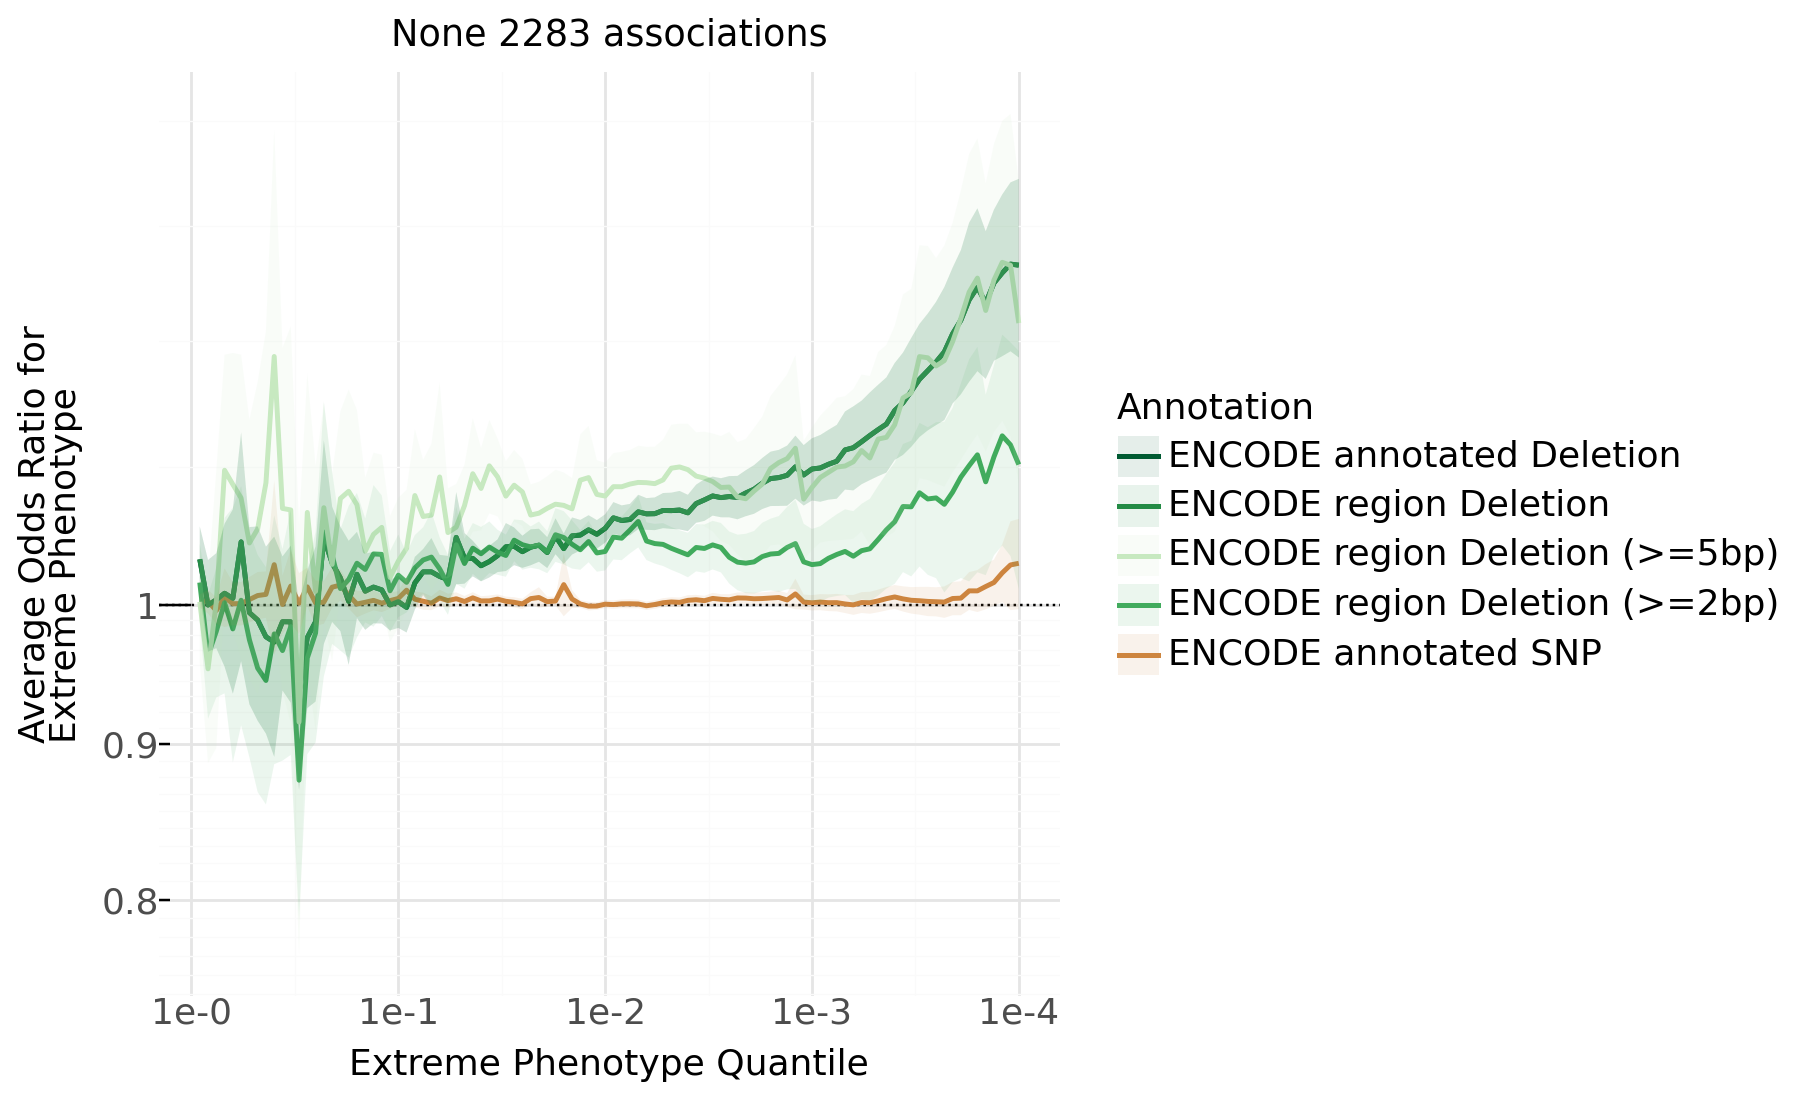

In [11]:
# Determine legend order based on final average odds ratio
legend_order = (
    plt_df.sort("neg_log_pheno_cutoff_inv")
    .group_by("label", maintain_order=True)
    .last()
    .sort("avg_odds_ratio", descending=True)
    ['label']
    .to_list()
)

# Generate breaks and labels for x-axis
start_exp = int(-np.log10(or_threshold_pheno_left))
end_exp = int(-np.log10(or_threshold_pheno_right))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"1e-{b}" for b in breaks_linear]

color_dict = dict(zip(plt_df['label'], plt_df['color']))

(
    ggplot(
        plt_df,
        aes(x='neg_log_pheno_cutoff_inv', y='avg_odds_ratio')
    )
    + geom_hline(aes(yintercept=1), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.1)
    + scale_fill_manual(values=color_dict, limits=legend_order)
    + scale_color_manual(values=color_dict, limits=legend_order)
    + labs(
        title=f"{pheno_list_type} {or_df[['gene_name', 'phenotype']].unique().shape[0]} associations",
        y=f"Average Odds Ratio for\nExtreme Phenotype",
        x="Extreme Phenotype Quantile",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + scale_y_log10()
    + annotation_logticks(sides="l")
    + theme_minimal()
    + theme(
        figure_size=(9, 5.5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [12]:
plt_df.filter(
    (pl.col('pheno_cutoff')==0.99) &
    (pl.col('annotation').is_in(['loftee_hc']))
)

annotation,neg_log_pheno_cutoff_inv,pheno_cutoff,pheno_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,f64,f64,u64,f64,f64,f64,f64,f64,str,str


In [13]:
melted_anno.filter(
    (pl.col('annotation')=='loftee_hc') &
    (pl.col('annotation_score_dircor')==1)
)

id,region,gene_name,annotation,annotation_score,category,annotation_dir,annotation_score_dircor
str,str,str,str,f32,str,i8,f32
